# Per-Trial Context Viewer

For each trial in a session this notebook generates a 4-panel figure:
- **Top-left** – XY headstage tracking trajectory over the video background frame (plasma: dark=start, bright=end)
- **Top-right** – Graph node-visit sequence shown as curved arrows (plasma colormap, same convention)
- **Middle** – Raster of ±N surrounding trials with the current trial marked in gold
- **Bottom** – Rolling % correct and % reward (window size configurable)

Trajectory panels are adapted from `align_frames_trials.ipynb` cell 176.  
Raster/rolling panels are adapted from `raster_plot.ipynb`.  
Graph G is built from `FullMazeGrid.pkl` (cell 73).  
Port map follows the date-based R55/R59 swap convention (cell 94).

In [1]:
import os, re, pickle, datetime, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from pathlib import Path
import scipy.io as sio

try:
    import cv2
    _CV2_AVAILABLE = True
except ImportError:
    _CV2_AVAILABLE = False
    warnings.warn("cv2 not found — XY trajectory panels will use a plain gray background")

In [10]:
# ── Fixed resource paths ──────────────────────────────────────────────────────
BPOD_SESSION_DATA = Path("/var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC1/maze_pairs_fix/Session Data")
OUTPUTS_ROOT      = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs")
RESOURCES         = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources")
FULL_MAZE_GRID    = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl")

# ── Session-level config (edit these before running) ─────────────────────────
folder_name    = '10_09_2025'   # session folder name
video_path     = '/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_videos/NPC1_2025_09_10.mp4'           # set to Path('/path/to/maze_video.mp4') or None
N              = 50             # raster window: show ±N trials around the current trial
rolling_window = 10             # rolling average window size for % correct / % reward

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Raster data extraction  (from raster_plot.ipynb)
# ─────────────────────────────────────────────────────────────────────────────

def did_receive_reward(tr, port_num, thr):
    try:
        reward_key = f"Reward{int(port_num)}"
        if 'States' not in tr or reward_key not in tr['States']:
            return False
        v = np.array(tr['States'][reward_key])
        return (v[0, 1] - v[0, 0] if v.ndim == 2 else v[1] - v[0]) > thr
    except Exception:
        return False


def extract_raster_data(session_data, thr=0.0002):
    ports_all  = session_data['TrialTypes'][1:]
    raw_trials = session_data['RawEvents']['Trial']
    if isinstance(raw_trials, dict):
        raw_trials = [raw_trials]
    n_seq     = min(len(ports_all), len(raw_trials) - 1)
    ports_all = np.array(ports_all[:n_seq])
    rf_all    = np.array([did_receive_reward(raw_trials[t], ports_all[t], thr)
                          for t in range(n_seq)])
    blk_sig   = np.zeros(n_seq)
    blocks    = session_data.get('Blocks', [])
    for i in range(n_seq):
        if i < len(blocks):
            v = blocks[i]
            if isinstance(v, (list, np.ndarray)) and len(v) >= 2:
                vv = np.sort(v)
                blk_sig[i] = 10 * vv[0] + vv[1]
    port_colors = np.array([
        [0.80, 0.25, 0.33], [1.00, 0.55, 0.50],
        [0.20, 0.45, 0.80], [0.55, 0.75, 1.00],
        [0.25, 0.60, 0.35], [0.65, 0.80, 0.55],
        [0.55, 0.40, 0.70], [0.90, 0.60, 0.85]
    ])
    return rf_all, ports_all, blk_sig, port_colors, n_seq


def choose_trial_tick_step(n):
    if n <= 100:   return 10
    if n <= 250:   return 25
    if n <= 600:   return 50
    if n <= 1200:  return 100
    return 200


def _set_raster_xticks(ax, trial_nums, x_spacing):
    step       = choose_trial_tick_step(len(trial_nums))
    first_tick = int(np.ceil(trial_nums[0] / step) * step)
    ticks      = list(range(first_tick, int(trial_nums[-1]) + 1, step))
    if not ticks or ticks[0] != trial_nums[0]:
        ticks.insert(0, int(trial_nums[0]))
    if ticks[-1] != trial_nums[-1]:
        ticks.append(int(trial_nums[-1]))
    ax.set_xticks(np.array(ticks) * x_spacing)
    ax.set_xticklabels([str(t) for t in ticks])


def draw_raster_panel(ax, rf, ports, blk_sig, tr_idx, trial_nums,
                      session_data, port_colors, x_spacing, title_str,
                      show_legend, show_xlabel):
    n_use             = len(rf)
    x_vals            = trial_nums * x_spacing
    pastel_frac       = 0.15
    first_block_color = np.array([0.92, 0.92, 0.92])

    if np.any(blk_sig != 0):
        s = blk_sig.astype(float).copy()
        s[s == 0] = -np.inf
        run_start      = 0
        first_captured = False
        blocks = session_data.get('Blocks', [])
        for i in range(1, n_use + 1):
            if i == n_use or s[i] != s[i - 1]:
                if np.isfinite(s[i - 1]):
                    x1 = x_vals[run_start] - 0.5 * x_spacing
                    x2 = x_vals[i - 1]    + 0.5 * x_spacing
                    abs_tr = int(tr_idx[run_start]) - 1
                    c = np.array([0.92, 0.92, 0.92])
                    if abs_tr < len(blocks):
                        v = blocks[abs_tr]
                        if isinstance(v, (list, np.ndarray)) and len(v) >= 2:
                            b_idx = [int(p) - 1 for p in np.sort(v)[:2]]
                            c = 1 - (1 - np.mean(port_colors[b_idx], axis=0)) * pastel_frac
                    if not first_captured:
                        first_block_color = c; first_captured = True
                    ax.fill_between([x1, x2], 0.5, 8.5, color=c, edgecolor='none', alpha=1.0)
                run_start = i

    for p in range(1, 9):
        idx_p  = np.where(ports == p)[0]
        if not len(idx_p): continue
        col    = port_colors[p - 1]
        open_i = idx_p[~rf[idx_p]]
        fill_i = idx_p[rf[idx_p]]
        if len(open_i):
            ax.scatter(x_vals[open_i], np.full(len(open_i), p), s=60,
                       facecolors='none', edgecolors=col, linewidths=1.5, zorder=3)
        if len(fill_i):
            ax.scatter(x_vals[fill_i], np.full(len(fill_i), p), s=80,
                       facecolors=col, edgecolors='none', zorder=3)

    ax.set_xlim(x_vals[0] - 0.5 * x_spacing, x_vals[-1] + 0.5 * x_spacing)
    ax.set_ylim(0.5, 8.5)
    ax.set_yticks(range(1, 9))
    ax.set_yticklabels([f"Port {p}" for p in range(1, 9)])
    _set_raster_xticks(ax, trial_nums, x_spacing)
    ax.grid(True, axis='both', linestyle='-', alpha=0.5, zorder=0)
    if show_xlabel:
        ax.set_xlabel('Trial', fontsize=18, fontweight='bold')
    ax.set_ylabel('Chosen port', fontsize=18, fontweight='bold')
    ax.set_title(title_str, fontsize=18, fontweight='bold')
    ax.tick_params(labelsize=11)

    if show_legend:
        handles = [
            mlines.Line2D([], [], color='none', marker='o', markerfacecolor='none',
                          markeredgecolor=[0.25, 0.25, 0.25], markersize=8,
                          markeredgewidth=1.2, label='Omission'),
            mlines.Line2D([], [], color='none', marker='o',
                          markerfacecolor=[0.25, 0.25, 0.25],
                          markeredgecolor='none', markersize=8, label='Reward'),
            mpatches.Patch(facecolor=first_block_color, edgecolor='gray',
                           linewidth=0.8, label='Active block'),
        ]
        for p in range(1, 9):
            handles.append(mlines.Line2D([], [], color='none', marker='o',
                                          markerfacecolor=port_colors[p - 1],
                                          markeredgecolor='none', markersize=10,
                                          label=f'Port {p}'))
        ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)

    return x_vals


def draw_rolling_panel(ax, rf_all, ports_all, blk_sig, trial_nums, x_spacing, window):
    """% correct (dark blue) and % reward (light blue) rolling averages."""
    n       = len(rf_all)
    correct = np.full(n, np.nan)
    for i in range(n):
        sig = blk_sig[i]
        if sig > 0:
            p1, p2 = int(sig) // 10, int(sig) % 10
            correct[i] = float(int(ports_all[i]) in (p1, p2))

    s_correct = pd.Series(correct).rolling(window, min_periods=1).mean().values * 100
    s_reward  = pd.Series(rf_all.astype(float)).rolling(window, min_periods=1).mean().values * 100

    x = trial_nums * x_spacing
    ax.plot(x, s_correct, color=(0.05, 0.18, 0.55), lw=2.0, zorder=3,
            label=f'% Correct (w={window})')
    ax.plot(x, s_reward,  color=(0.45, 0.70, 0.95), lw=2.0, zorder=3,
            label=f'% Reward (w={window})')
    ax.axhline(50, color='gray', lw=0.8, linestyle='--', zorder=0)
    ax.set_xlim(x[0] - 0.5 * x_spacing, x[-1] + 0.5 * x_spacing)
    ax.set_ylim(-5, 105)
    ax.set_ylabel('%', fontsize=18, fontweight='bold')
    ax.set_xlabel('Trial', fontsize=18, fontweight='bold')
    ax.legend(loc='upper right', fontsize=18, frameon=True)
    ax.tick_params(labelsize=10)
    ax.grid(True, axis='both', linestyle='-', alpha=0.4)
    _set_raster_xticks(ax, trial_nums, x_spacing)
    return x

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Column resolution helpers  (from align_frames_trials.ipynb cell 176)
# ─────────────────────────────────────────────────────────────────────────────

def _resolve_column(df, candidates):
    """Find the first matching column in df given a list of candidate names (case-insensitive)."""
    cols        = df.columns
    candidate_l = [c.lower() for c in candidates]
    if isinstance(cols, pd.MultiIndex):
        for col in cols:
            parts = [str(v).strip().lower() for v in col]
            for candidate in candidate_l:
                if candidate in parts:
                    return col
        return None
    lower_map = {str(col).strip().lower(): col for col in cols}
    for candidate in candidate_l:
        if candidate in lower_map:
            return lower_map[candidate]
    return None


def _resolve_tracking_column(df, bodypart, field):
    """Find (bodypart, field) column supporting MultiIndex and flat column conventions."""
    cols = df.columns
    if isinstance(cols, pd.MultiIndex):
        for col in cols:
            if len(col) >= 2 and bodypart in col and field in [str(x).lower() for x in col]:
                return col
        return None
    for variant in [f'{bodypart}_{field}', f'{bodypart}.{field}', f'{bodypart}{field}']:
        if variant in cols:
            return variant
    return None


# ─────────────────────────────────────────────────────────────────────────────
# Trajectory panel drawing  (adapted from align_frames_trials.ipynb cell 176)
# ─────────────────────────────────────────────────────────────────────────────

def draw_xy_trajectory_ax(ax, summary_df, start_frame, end_frame, video_path=None,
                           node_positions=None, port_map=None, port_colors=None,
                           transform_matrix=None):
    """
    Draw the headstage XY tracking trajectory over a video background frame.
    start_frame / end_frame are values from the frame_idx_global column (aligned frame indices).
    Plasma colormap: dark purple = trial start, bright yellow = trial end.
    If video_path is None or cv2 is unavailable, uses a plain gray background.
    node_positions / port_map / port_colors: if provided, draws colored target labels.
    transform_matrix: 3x3 homography that maps FullMazeGrid coords → DLC video pixel space
                      (applied as M_inv @ grid_point to get DLC coords).
    """
    x_col = _resolve_tracking_column(summary_df, 'headstage', 'x')
    y_col = _resolve_tracking_column(summary_df, 'headstage', 'y')

    # Background: seek to the global frame index of trial start
    bg = None
    if video_path is not None and _CV2_AVAILABLE:
        cap = cv2.VideoCapture(str(video_path))
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))
        ret, frame = cap.read()
        cap.release()
        if ret:
            bg = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    if bg is None:
        bg = np.full((480, 640, 3), 200, dtype=np.uint8)
    ax.imshow(bg)

    if x_col is None or y_col is None:
        ax.set_title('XY Trajectory (headstage columns not found)', fontsize=18)
        ax.axis('off')
        return

    # Filter rows by frame_idx_global (aligned index), not by row position
    frame_idx_col = _resolve_column(summary_df, ['frame_idx_global'])
    if frame_idx_col is not None:
        window_df = summary_df[(summary_df[frame_idx_col] >= start_frame) &
                                (summary_df[frame_idx_col] <= end_frame)]
    else:
        window_df = summary_df.iloc[int(start_frame):int(end_frame) + 1]

    track     = window_df[[x_col, y_col]].dropna()
    x_vals    = track[x_col].values.astype(float)
    y_vals    = track[y_col].values.astype(float)

    if len(x_vals) > 1:
        time_norm = np.linspace(0, 1, len(x_vals))
        points    = np.array([x_vals, y_vals]).T.reshape(-1, 1, 2)
        segs      = np.concatenate([points[:-1], points[1:]], axis=1)
        lc        = LineCollection(segs, cmap='plasma', norm=plt.Normalize(0, 1),
                                   linewidths=2.5, alpha=0.85, zorder=3)
        lc.set_array(time_norm)
        ax.add_collection(lc)
        cbar = plt.colorbar(lc, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Start', 'End'])
        cbar.set_label('Time', fontsize=18)
        cbar.ax.tick_params(labelsize=7)
        ax.scatter(x_vals[0],  y_vals[0],  s=80, c='lime', zorder=5, edgecolors='k', lw=0.8)
        ax.scatter(x_vals[-1], y_vals[-1], s=80, c='red',  zorder=5, edgecolors='k', lw=0.8)

    # Draw colored target labels in DLC video space
    if node_positions is not None and port_map is not None and port_colors is not None:
        tm_inv       = np.linalg.inv(transform_matrix) if transform_matrix is not None else None
        label_offset = 30
        for node, (nx_p, ny_p) in node_positions.items():
            if node not in port_map:
                continue
            port_num = port_map[node]
            color    = port_colors[port_num - 1]
            if tm_inv is not None:
                pt  = np.array([nx_p, ny_p, 1.0])
                dlc = tm_inv @ pt
                dlc /= dlc[2]
                px, py = float(dlc[0]), float(dlc[1])
            else:
                px, py = nx_p, ny_p
            ax.scatter(px, py, s=100, c=[color], zorder=6,
                       edgecolors='black', linewidths=0.8)
            if port_num <= 4:   # top ports — label above
                ax.text(px, py - label_offset, f"T{port_num}",
                        color=color, ha='center', va='bottom',
                        fontsize=18, fontweight='bold', zorder=7, clip_on=False,
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                                  alpha=1, edgecolor='none'))
            else:               # bottom ports — label below
                ax.text(px, py + label_offset, f"T{port_num}",
                        color=color, ha='center', va='top',
                        fontsize=18, fontweight='bold', zorder=7, clip_on=False,
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                                  alpha=1, edgecolor='none'))

    ax.axis('off')
    ax.set_title('XY Tracking Trajectory', fontsize=18, fontweight='bold')


def draw_graph_trajectory_ax(ax, trial_idx, traversal_df,
                              G, node_positions, port_map, port_colors,
                              start_frame=None, end_frame=None):
    """
    Draw the graph node-visit sequence as straight lines with plasma colormap.
    Node sequence comes from traversal_df filtered by start_frame/end_frame (global frame indices)
    when provided, otherwise falls back to trial_idx.
    port_map: {node_name: port_number (1-indexed)}
    port_colors: (8, 3) array — row index = port_number - 1.
    """
    # Draw base graph structure (light gray)
    for n1, n2 in G.edges():
        if n1 in node_positions and n2 in node_positions:
            x1, y1 = node_positions[n1]
            x2, y2 = node_positions[n2]
            ax.plot([x1, x2], [y1, y2], color='lightgray', lw=0.8, zorder=1)

    # Compute tight axes bounds from node positions to avoid empty whitespace
    all_x   = [p[0] for p in node_positions.values()]
    all_y   = [p[1] for p in node_positions.values()]
    x_range = max(all_x) - min(all_x)
    y_range = max(all_y) - min(all_y)
    pad_x   = 0.06 * x_range
    pad_y   = 0.15 * y_range   # extra vertical room for T-labels
    ax.set_xlim(min(all_x) - pad_x, max(all_x) + pad_x)
    ax.set_ylim(max(all_y) + pad_y, min(all_y) - pad_y)   # inverted y (image coords)

    label_offset = 25
    for node, (nx_pos, ny_pos) in node_positions.items():
        if node in port_map:
            port_num = port_map[node]
            color    = port_colors[port_num - 1]
            ax.scatter(nx_pos, ny_pos, s=200, c=[color], zorder=4,
                       edgecolors='black', linewidths=0.8)
            if port_num <= 4:   # top ports — label above (smaller y = visually higher)
                ax.text(nx_pos, ny_pos - label_offset, f"T{port_num}",
                        color=color, ha='center', va='bottom',
                        fontsize=18, fontweight='bold', zorder=5, clip_on=False)
            else:               # bottom ports — label below (larger y = visually lower)
                ax.text(nx_pos, ny_pos + label_offset, f"T{port_num}",
                        color=color, ha='center', va='top',
                        fontsize=18, fontweight='bold', zorder=5, clip_on=False)
        else:
            ax.scatter(nx_pos, ny_pos, s=40, c='#CCCCCC', zorder=2,
                       edgecolors='none', linewidths=0)

    # Get node sequence for this trial's frame window (same boundaries as XY trajectory)
    if start_frame is not None and end_frame is not None:
        trial_trav = traversal_df[
            (traversal_df['start_frame_global'] >= start_frame) &
            (traversal_df['start_frame_global'] <= end_frame)
        ]
    else:
        trial_trav = traversal_df[traversal_df['trial_idx'] == trial_idx]

    node_rows   = (trial_trav[trial_trav['location_type'] == 'node']
                   .sort_values('start_frame_global'))
    node_seq    = node_rows['headstage_graph_node'].dropna().values
    valid_nodes = [str(n) for n in node_seq if str(n) in node_positions]

    if len(valid_nodes) > 1:
        xs = [node_positions[n][0] for n in valid_nodes]
        ys = [node_positions[n][1] for n in valid_nodes]
        n  = len(valid_nodes)

        points    = np.array([xs, ys]).T.reshape(-1, 1, 2)
        segs      = np.concatenate([points[:-1], points[1:]], axis=1)
        time_norm = np.linspace(0, 1, n - 1)
        lc = LineCollection(segs, cmap='plasma', norm=plt.Normalize(0, 1),
                            linewidths=2.5, alpha=0.85, zorder=3)
        lc.set_array(time_norm)
        ax.add_collection(lc)

        cbar = plt.colorbar(lc, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Start', 'End'])
        cbar.set_label('Node visit #', fontsize=18)
        cbar.ax.tick_params(labelsize=7)

        ax.scatter(xs[0],  ys[0],  s=100, c='lime', zorder=6, edgecolors='k', lw=0.8)
        ax.scatter(xs[-1], ys[-1], s=100, c='red',  zorder=6, edgecolors='k', lw=0.8)

    ax.axis('off')
    ax.set_title('Graph Trajectory', fontsize=18, fontweight='bold')


# ─────────────────────────────────────────────────────────────────────────────
# Reward-based trial boundary computation
# ─────────────────────────────────────────────────────────────────────────────

def compute_reward_frame_indices(session_data, summary_df):
    """
    Return (n_trials,) float array of frame_idx_global at reward delivery start.
    NaN for trials where no reward was given.
    """
    ports_all  = session_data['TrialTypes'][1:]
    raw_trials = session_data['RawEvents']['Trial']
    if isinstance(raw_trials, dict):
        raw_trials = [raw_trials]
    n_trials = min(len(ports_all), len(raw_trials) - 1)

    tid_col       = ('trial_idx', '') if ('trial_idx', '') in summary_df.columns else 'trial_idx'
    ftime_col     = ('frame_time_in_trial', '') if ('frame_time_in_trial', '') in summary_df.columns else 'frame_time_in_trial'
    frame_idx_col = _resolve_column(summary_df, ['frame_idx_global'])

    reward_frames = np.full(n_trials, np.nan)
    for t in range(n_trials):
        port_num   = int(ports_all[t])
        tr         = raw_trials[t]
        reward_key = f"Reward{port_num}"
        try:
            if 'States' not in tr or reward_key not in tr['States']:
                continue
            v = np.array(tr['States'][reward_key], dtype=float)
            reward_time = float(v[0, 0] if v.ndim == 2 else v[0])
            if np.isnan(reward_time) or reward_time < 0:
                continue
            trial_rows = summary_df[summary_df[tid_col] == t]
            if len(trial_rows) == 0:
                continue
            times   = trial_rows[ftime_col].values.astype(float)
            closest = int(np.argmin(np.abs(times - reward_time)))
            reward_frames[t] = int(trial_rows[frame_idx_col].iloc[closest])
        except Exception:
            continue
    return reward_frames

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Combined 4-panel figure per trial
# ─────────────────────────────────────────────────────────────────────────────

def make_trial_context_figure(trial_idx, summary_df, traversal_df, session_data,
                               session_date, session_time,
                               G, node_positions, port_map, port_colors,
                               video_path=None, N=50, rolling_window=10,
                               transform_matrix=None):
    """
    Build a 4-panel figure for one trial:
      [top-left]   XY tracking trajectory over video background (with colored target labels)
      [top-right]  Graph node-visit sequence (straight lines, plasma, from traversal_df)
      [middle]     Raster of trials [trial-N .. trial+N]; current trial in gold
      [bottom]     Rolling % correct + % reward for the same window

    trial_idx      : 0-indexed trial index
    summary_df     : per-frame DataFrame; must contain frame_idx_global and trial_idx columns
    traversal_df   : graph-logic-corrected traversal sequence (traversal_df.csv)
    transform_matrix : 3x3 homography (FullMazeGrid → DLC video pixel space) for target labels
    """
    thr       = 0.0002
    x_spacing = 1.8
    rf_all, ports_all, blk_sig, _, n_seq = extract_raster_data(session_data, thr)

    t0  = max(0, trial_idx - N)
    t1  = min(n_seq - 1, trial_idx + N)
    idx = np.arange(t0, t1 + 1)
    trial_nums_win = idx + 1

    # Frame-index columns
    tid_col       = ('trial_idx', '') if ('trial_idx', '') in summary_df.columns else 'trial_idx'
    frame_idx_col = _resolve_column(summary_df, ['frame_idx_global'])
    trial_mask    = summary_df[tid_col] == trial_idx

    # Fallback frame boundaries from trial_idx assignment
    if frame_idx_col is not None:
        trial_frames   = summary_df.loc[trial_mask, frame_idx_col].dropna()
        fallback_start = int(trial_frames.min()) if len(trial_frames) > 0 else 0
        fallback_end   = int(trial_frames.max()) if len(trial_frames) > 0 else 0
    else:
        trial_rows     = np.where(trial_mask.values)[0]
        fallback_start = int(trial_rows[0])  if len(trial_rows) > 0 else 0
        fallback_end   = int(trial_rows[-1]) if len(trial_rows) > 0 else 0

    # Reward-based frame boundaries: trial starts when previous reward was given,
    # ends when this trial's reward is given
    reward_frames = compute_reward_frame_indices(session_data, summary_df)
    if trial_idx > 0 and not np.isnan(reward_frames[trial_idx - 1]):
        start_frame = int(reward_frames[trial_idx - 1]) + 1
    else:
        start_frame = fallback_start
    if trial_idx < len(reward_frames) and not np.isnan(reward_frames[trial_idx]):
        end_frame = int(reward_frames[trial_idx])
    else:
        end_frame = fallback_end

    n_frames = end_frame - start_frame + 1

    # Count node visits within the same reward-based frame window
    trial_trav    = traversal_df[
        (traversal_df['start_frame_global'] >= start_frame) &
        (traversal_df['start_frame_global'] <= end_frame)
    ]
    n_node_visits = int((trial_trav['location_type'] == 'node').sum())

    # Layout: 3 rows, top row split into 2 columns
    # constrained_layout with minimal padding to eliminate excess whitespace
    fig    = plt.figure(figsize=(20, 16), facecolor='white', layout='constrained')
    fig.get_layout_engine().set(h_pad=2/72, hspace=0.02, w_pad=4/72, wspace=0.04)
    gs     = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[4.5, 1.2, 0.6])
    gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0])
    ax_xy     = fig.add_subplot(gs_top[0])
    ax_graph  = fig.add_subplot(gs_top[1])
    ax_raster = fig.add_subplot(gs[1])
    ax_roll   = fig.add_subplot(gs[2])

    draw_xy_trajectory_ax(ax_xy, summary_df, start_frame, end_frame, video_path,
                          node_positions=node_positions, port_map=port_map,
                          port_colors=port_colors, transform_matrix=transform_matrix)
    draw_graph_trajectory_ax(ax_graph, trial_idx, traversal_df,
                              G, node_positions, port_map, port_colors,
                              start_frame=start_frame, end_frame=end_frame)

    draw_raster_panel(
        ax_raster, rf_all[idx], ports_all[idx], blk_sig[idx],
        trial_nums_win, trial_nums_win, session_data, port_colors, x_spacing,
        f"Trials {t0 + 1}–{t1 + 1}  (current: trial {trial_idx + 1})",
        show_legend=True, show_xlabel=False
    )
    cur_x = (trial_idx + 1) * x_spacing
    ax_raster.axvline(cur_x, color='#FFD700', lw=3.5, zorder=10)

    draw_rolling_panel(ax_roll, rf_all[idx], ports_all[idx], blk_sig[idx],
                       trial_nums_win, x_spacing, rolling_window)
    ax_roll.axvline(cur_x, color='#FFD700', lw=3.5, zorder=10)

    fig.suptitle(
        f"{session_date} {session_time}  |  Trial {trial_idx + 1}  "
        f"({n_frames} frames,  {n_node_visits} node visits)",
        fontsize=12, fontweight='bold'
    )
    return fig

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Session loading helpers
# ─────────────────────────────────────────────────────────────────────────────

def get_port_map(folder_name):
    """Return {node_name: port_number (1-8)} applying the R55/R59 swap after 07/09/2025."""
    parts = folder_name.split('_')
    dd, mm = parts[0], parts[1]
    if mm == '09' and dd in {'07', '08', '09', '10', '11'}:
        return {'R522': 1, 'R526': 2, 'L56': 3, 'L510': 4,
                'L521': 5, 'L525': 6, 'R59': 7, 'R55': 8}
    return {'R522': 1, 'R526': 2, 'L56': 3, 'L510': 4,
            'L521': 5, 'L525': 6, 'R55': 7, 'R59': 8}


def find_mat_file(folder_name):
    parts      = folder_name.split('_')
    date_str   = f"{parts[2]}{parts[1]}{parts[0]}"
    candidates = list(BPOD_SESSION_DATA.glob(f'*{date_str}*.mat'))
    subfolder  = BPOD_SESSION_DATA / folder_name
    if subfolder.is_dir():
        candidates += list(subfolder.glob(f'*{date_str}*.mat'))
    return sorted(candidates)[0] if candidates else None


def build_graph_from_full_maze(pkl_path=None):
    """
    Build G (nx.DiGraph) and node_positions from FullMazeGrid.pkl.
    Mirrors align_frames_trials.ipynb cell 73.
    """
    if pkl_path is None:
        pkl_path = FULL_MAZE_GRID
    with open(pkl_path, 'rb') as f:
        mapping_data = pickle.load(f)
    nodes_dict = mapping_data['mappings']['nodes']
    edges_dict = mapping_data['mappings']['edges']

    node_positions = {}
    for node_id, polygon_list in nodes_dict.items():
        polygon = polygon_list[0] if polygon_list else []
        if polygon and len(polygon) >= 2:
            xs = [p[0] for p in polygon]
            ys = [p[1] for p in polygon]
            node_positions[node_id] = (sum(xs) / len(xs), sum(ys) / len(ys))

    G = nx.DiGraph()
    G.add_nodes_from(node_positions.keys())
    for edge_key in edges_dict:
        parts = edge_key.split('_')
        if len(parts) == 2:
            a, b = parts
            if a in node_positions and b in node_positions:
                G.add_edge(a, b)
                G.add_edge(b, a)
    print(f"Graph: {len(G.nodes())} nodes, {len(G.edges())} directed edges")
    return G, node_positions


def load_session(folder_name, video_path=None):
    """Load all per-session assets. Returns a dict or None on failure."""
    sess_dir = OUTPUTS_ROOT / folder_name
    mat_file = find_mat_file(folder_name)
    if mat_file is None:
        print(f"No .mat file for {folder_name}"); return None
    try:
        mat_data = sio.loadmat(str(mat_file), simplify_cells=True)
    except Exception as e:
        print(f".mat load error: {e}"); return None
    if 'SessionData' not in mat_data:
        print("No SessionData in .mat"); return None

    match = re.search(r'(\d{8})_(\d{6})', mat_file.name)
    if match:
        d, t = match.groups()
        session_date = f"{d[:4]}-{d[4:6]}-{d[6:8]}"
        session_time = f"{t[:2]}:{t[2:4]}:{t[4:6]}"
        stamp        = f"{d}_{t}"
    else:
        session_date = session_time = stamp = folder_name

    summary_pkl = sess_dir / 'summary_df.pkl'
    if not summary_pkl.exists():
        print(f"Missing {summary_pkl}"); return None
    summary_df = pd.read_pickle(str(summary_pkl))

    traversal_csv = sess_dir / 'traversal_df.csv'
    if not traversal_csv.exists():
        print(f"Missing {traversal_csv}"); return None
    traversal_df = pd.read_csv(str(traversal_csv))

    port_map = get_port_map(folder_name)
    _, _, _, port_colors, _ = extract_raster_data(mat_data['SessionData'])
    G, node_positions = build_graph_from_full_maze()

    # Load per-session transform matrix (FullMazeGrid → DLC video pixel space)
    parts          = folder_name.split('_')
    dd, mm, yyyy   = parts[0], parts[1], parts[2]
    tm_session     = RESOURCES / 'transform_matrix' / f'{yyyy}_{mm}_{dd}.npy'
    tm_default     = RESOURCES / 'transform_matrix.npy'
    if tm_session.exists():
        transform_matrix = np.load(str(tm_session))
    elif tm_default.exists():
        transform_matrix = np.load(str(tm_default))
    else:
        transform_matrix = None
        print("Warning: no transform_matrix found — target labels will use raw grid coords")

    return dict(
        sess_dir=sess_dir, session_data=mat_data['SessionData'],
        session_date=session_date, session_time=session_time, stamp=stamp,
        summary_df=summary_df, traversal_df=traversal_df,
        G=G, node_positions=node_positions,
        port_map=port_map, port_colors=port_colors,
        video_path=video_path, transform_matrix=transform_matrix
    )

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Batch runner: one figure per trial
# ─────────────────────────────────────────────────────────────────────────────

def process_trial_context_figures(folder_name, video_path=None,
                                   N=50, rolling_window=10, max_trials=None):
    """
    Generate and save one 4-panel figure per trial.
    Output: OUTPUTS_ROOT/<folder_name>/trial_context_figures/trial_NNNN.png
    Already-saved trials are skipped so the run is resumable.
    """
    res = load_session(folder_name, video_path)
    if res is None:
        return

    out_dir = res['sess_dir'] / 'trial_context_figures'
    out_dir.mkdir(parents=True, exist_ok=True)

    tid_col    = ('trial_idx', '') if ('trial_idx', '') in res['summary_df'].columns else 'trial_idx'
    all_trials = sorted(res['summary_df'][tid_col].unique())
    if max_trials is not None:
        all_trials = all_trials[:max_trials]
    print(f"{len(all_trials)} trials → {out_dir}")

    for trial_idx in all_trials:
        out_path = out_dir / f'trial_{int(trial_idx) + 1:04d}.png'
        if out_path.exists():
            continue
        try:
            fig = make_trial_context_figure(
                trial_idx, res['summary_df'], res['traversal_df'], res['session_data'],
                res['session_date'], res['session_time'],
                res['G'], res['node_positions'],
                res['port_map'], res['port_colors'],
                video_path=res['video_path'],
                N=N, rolling_window=rolling_window,
                transform_matrix=res.get('transform_matrix')
            )
            fig.savefig(str(out_path), dpi=150, bbox_inches='tight')
            plt.close(fig)
        except Exception as e:
            import traceback
            print(f"Trial {int(trial_idx) + 1}: {e}")
            traceback.print_exc()

    print(f"Done: {folder_name}")

Graph: 126 nodes, 250 directed edges


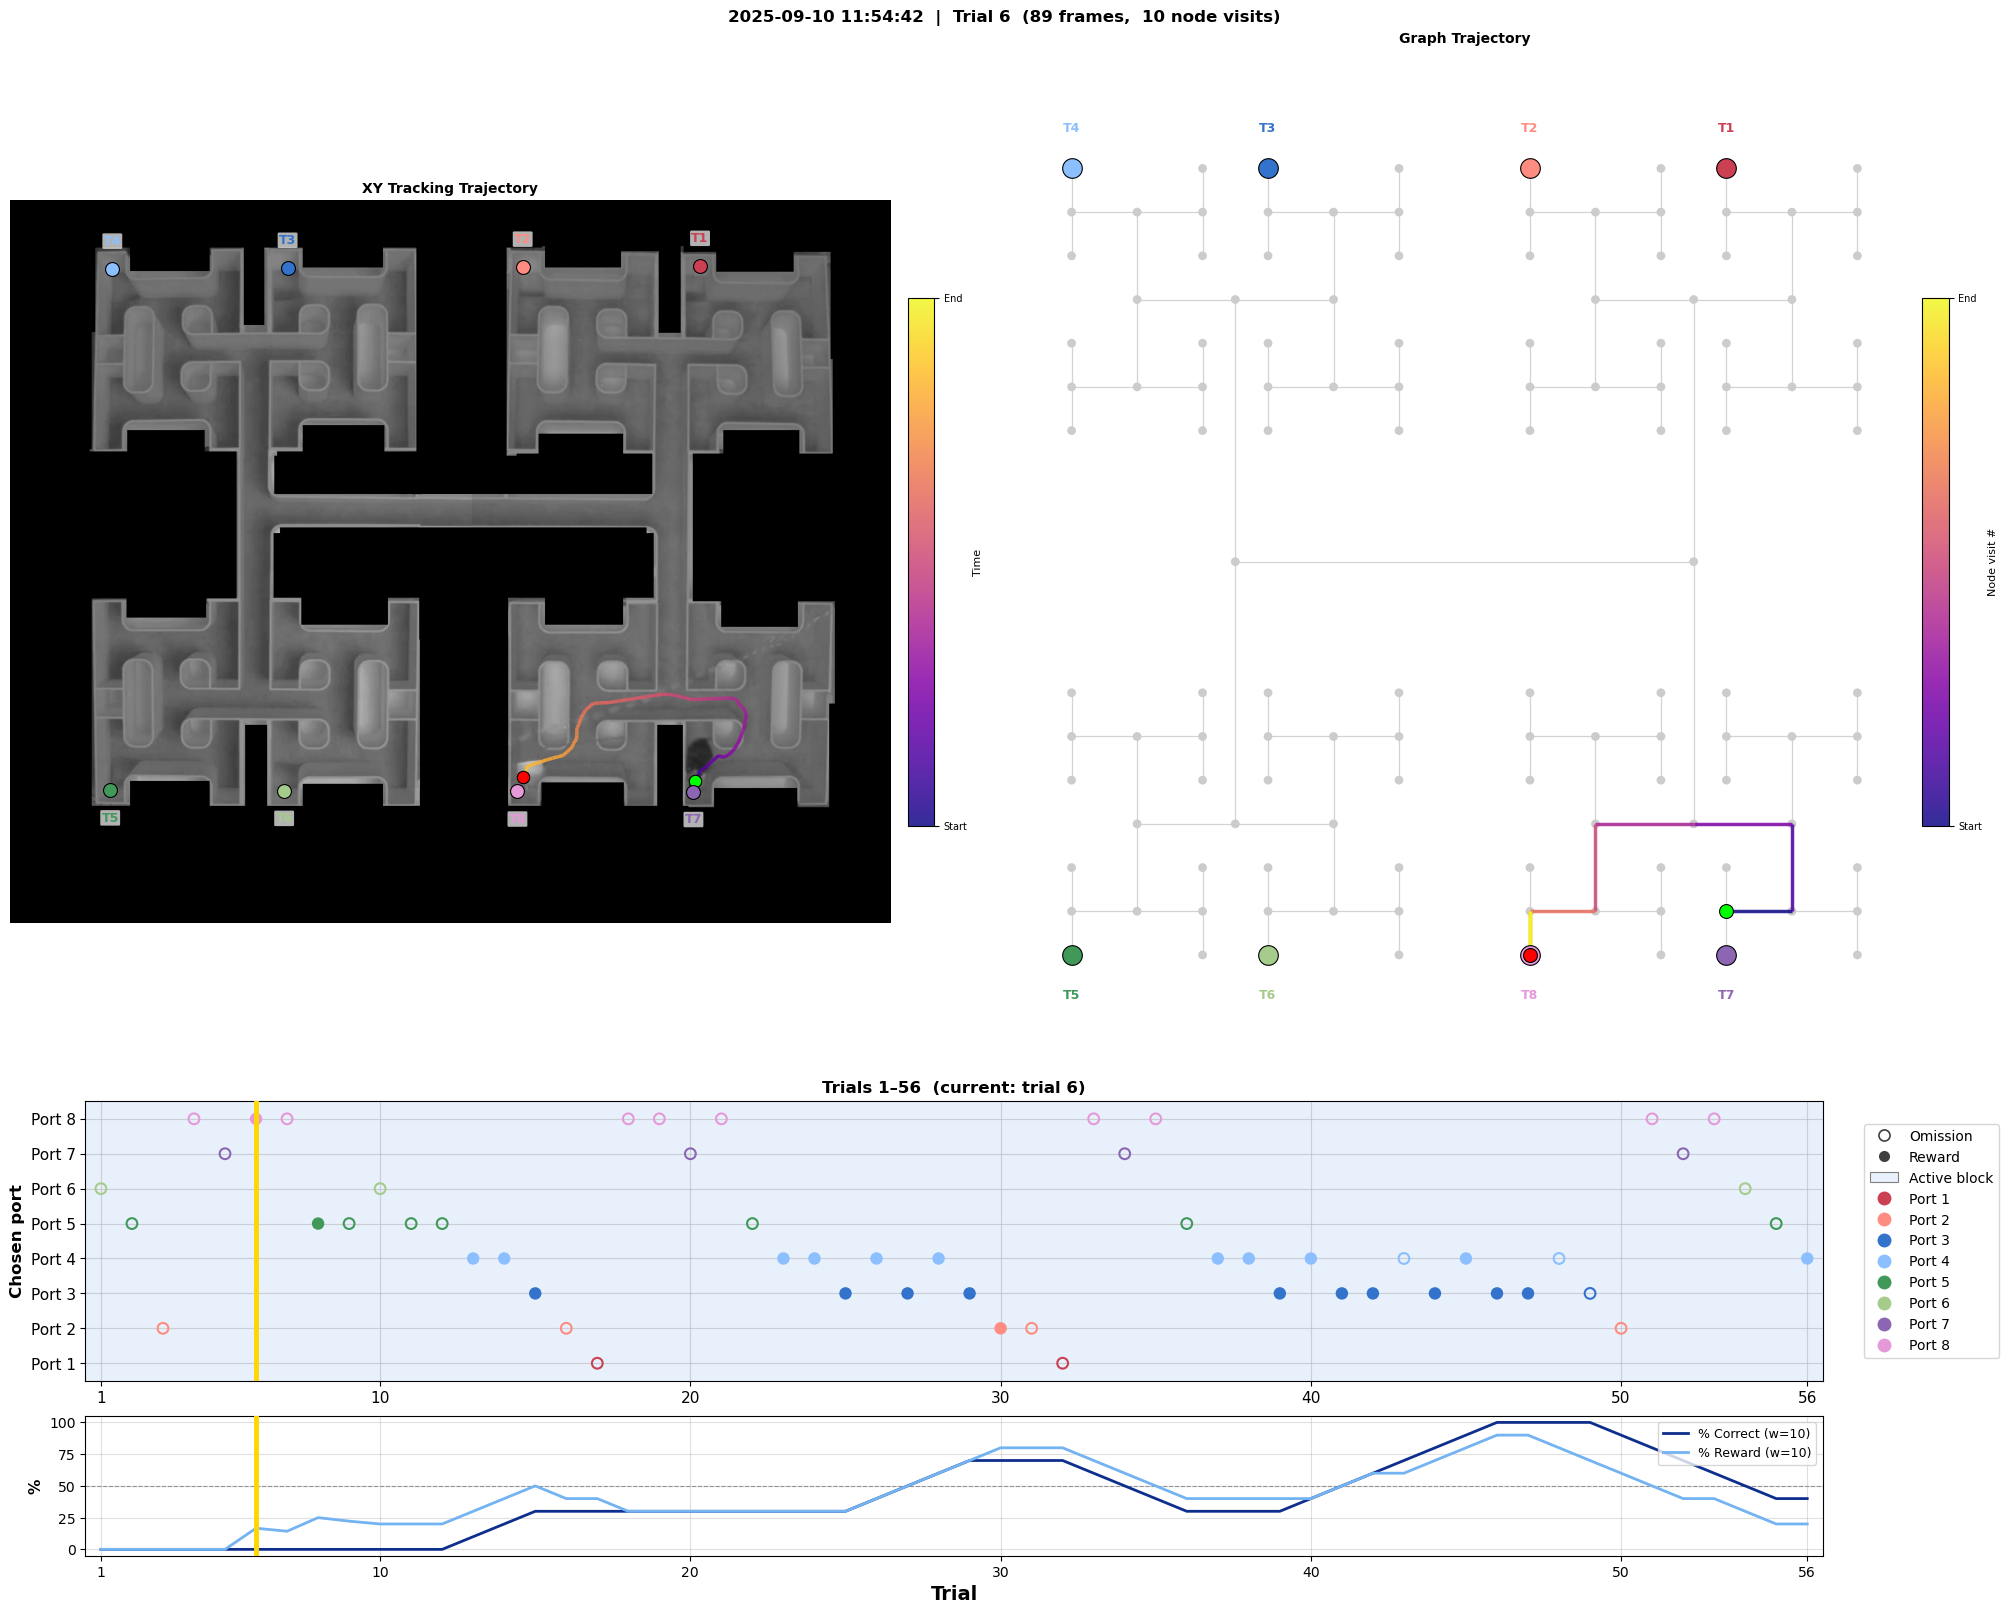

In [16]:
# ── Quick inline test: preview a single trial before running the full batch ───
res = load_session(folder_name, video_path=video_path)

fig = make_trial_context_figure(
    trial_idx=5,
    summary_df=res['summary_df'],
    traversal_df=res['traversal_df'],
    session_data=res['session_data'],
    session_date=res['session_date'],
    session_time=res['session_time'],
    G=res['G'],
    node_positions=res['node_positions'],
    port_map=res['port_map'],
    port_colors=res['port_colors'],
    video_path=res['video_path'],
    N=N, rolling_window=rolling_window,
    transform_matrix=res.get('transform_matrix')
)
plt.show()

In [17]:
# ── Generate figures for all trials in the session ────────────────────────────
process_trial_context_figures(
    folder_name,
    video_path=video_path,
    N=N,
    rolling_window=rolling_window
)
print("Done.")

Graph: 126 nodes, 250 directed edges
737 trials → /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/trial_context_figures
Done: 10_09_2025
Done.
